# NovaBank: Predictive Retention at Scale
### Analytics Methods and Frameworks Project

**Prepared By:** Ruth Ngiciri

**Date:** 13 September 2026

**Business case:** NovaBank — Predictive Retention at Scale


## 1. Problem Framing and Scope

**Problem brief.** NovaBank's margins are under pressure from customer attrition, and the retention team currently reaches out reactively rather than proactively. The decision this analysis informs is *which customers the retention team should proactively contact next cycle, and with how much confidence*. The primary stakeholders are the Head of Customer Success, the retention/call-center operations team, and compliance (who must be able to defend the targeting logic). The model needs to run every contact cycle (assumed monthly) and must work within the team's existing outreach capacity. Key constraints are a limited number of outreach slots per cycle, a need for the targeting logic to be explainable to non-technical stakeholders, and fairness across customer demographics.

**Translating the business problem into an analytics problem.** We frame this as a **binary classification** problem: predict the probability that a customer will respond positively to a proactive retention/relationship-deepening contact (`target = 1`) versus not (`target = 0`). Customers ranked highest by predicted probability are prioritized for outreach, subject to the team's contact capacity.

**Success measures.**
1. **Precision within the contacted segment** (at the chosen capacity/threshold) — how many of the people we contact are actually worth contacting (drives wasted-offer cost).
2. **Recall of the top segment** — what share of all positive responders we would have captured (drives missed-opportunity cost).
We also track ROC-AUC and PR-AUC as threshold-independent measures of overall model discrimination.

**Action the analysis should inform:** *"Contact the top ~15% of customers by predicted response propensity each cycle"* — the exact operating point is derived below from a cost/capacity trade-off, not assumed up front.

**Data & assumption note.** The dataset supplied for this case is a bank direct-marketing dataset (customer profile + a past outreach campaign, with `y` indicating whether the customer accepted the offer). It does not contain a literal "churn" flag. Per the assignment FAQ ("you may simulate additional data... as long as you document your assumptions"), we treat `y = 1` (accepted the offer) as a proxy for *"customer is retainable / responds well to proactive outreach"*, and `y = 0` as the group that did not respond to standard outreach and represents higher attrition risk. This is an explicit, documented modeling assumption — not a claim that this is literally historical churn data.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RAW_PATH = '../data/DataSet.csv'  # place the provided DataSet.csv in the same folder as this notebook


## 2. Data Readiness

### 2.1 Load and repair the file
The raw export wraps every row in an extra pair of quotes and doubles internal quote characters
(e.g. `"30;""blue-collar"";..."`). We strip the outer quote and un-escape the doubled quotes before
handing the text to `pandas.read_csv`.

In [46]:
with open(RAW_PATH, encoding='utf-8') as f:
    raw_lines = f.read().splitlines()

fixed_lines = []
for line in raw_lines:
    line = line.strip()
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1]
    line = line.replace('""', '"')
    fixed_lines.append(line)

df = pd.read_csv(StringIO('\n'.join(fixed_lines)), sep=';', quotechar='"')
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()


Rows: 4,119   Columns: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


### 2.2 Data dictionary

| Field | Description |
|---|---|
| age | Customer age in years |
| job | Occupation category |
| marital | Marital status |
| education | Education level |
| default | Has credit in default? (yes/no/unknown) |
| housing | Has a housing loan? |
| loan | Has a personal loan? |
| contact | Contact communication channel (cellular/telephone) |
| month | Month of last contact |
| day_of_week | Day of week of last contact |
| duration | Last contact duration, seconds — **excluded from modeling, see below** |
| campaign | Number of contacts made during this campaign for this customer |
| pdays | Days since the customer was last contacted from a previous campaign (999 = never contacted) |
| previous | Number of contacts before this campaign |
| poutcome | Outcome of the previous campaign |
| emp.var.rate | Employment variation rate (macro, quarterly) |
| cons.price.idx | Consumer price index (macro, monthly) |
| cons.conf.idx | Consumer confidence index (macro, monthly) |
| euribor3m | 3-month Euribor rate (macro, daily) |
| nr.employed | Number of employees (macro, quarterly) |
| y | Whether the customer accepted the offer — **our proxy retention/response target** |

### 2.3 Data quality checks

In [47]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("'unknown' counts by field:")
for c in df.select_dtypes(include='object').columns:
    n = (df[c] == 'unknown').sum()
    if n:
        print(f"  {c}: {n} ({n/len(df):.1%})")
print()
print("Missing values:", df.isnull().sum().sum())


Duplicate rows: 0

'unknown' counts by field:
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)

Missing values: 0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25284\2233148401.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


No duplicate rows and no true nulls. A handful of categorical fields carry an explicit `"unknown"` category
(most notably `default`, ~19%) — we keep `unknown` as its own category rather than imputing, since a customer's
unwillingness/inability to disclose default status may itself carry signal, and imputing would hide that.

### 2.4 Target definition and leakage check

`duration` (the length of the retention call) is only known **after** the call happens — it cannot be used to
decide *whom to call* in the first place, and it is famously predictive of the outcome in this dataset (long
calls tend to end in acceptance). Including it would leak post-decision information into a pre-decision model,
so **we drop `duration`** from the feature set, consistent with responsible use of this dataset.

In [48]:
df['target'] = (df['y'] == 'yes').astype(int)
print(f"Overall positive (retainable/responsive) rate: {df['target'].mean():.1%}")

feature_cols = [c for c in df.columns if c not in ('y', 'target', 'duration')]
X = df[feature_cols].copy()
y = df['target'].copy()

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print("Categorical features:", cat_cols)
print("Numeric features:", num_cols)


Overall positive (retainable/responsive) rate: 10.9%
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25284\1800028775.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


### 2.5 Train/test split

A stratified 75/25 split preserves the ~11% positive rate in both sets.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.mean():.1%} positive)")
print(f"Test:  {X_test.shape[0]:,} rows ({y_test.mean():.1%} positive)")


Train: 3,089 rows (10.9% positive)
Test:  1,030 rows (11.0% positive)


## 3. Model Building: Baseline & Improved Models

**Baseline — Logistic Regression** (class-balanced): a simple, fully explainable linear model. Coefficients
map directly to "this factor raises/lowers response odds," which is what compliance and non-technical
stakeholders need.

**Improved — Gradient Boosting Classifier**: captures non-linear interactions (e.g., macro conditions
interacting with contact history) that a linear model misses, at some cost to direct interpretability
(addressed in Section 5 with feature importance).

In [50]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

baseline = Pipeline([
    ('pre', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])
baseline.fit(X_train, y_train)
base_proba = baseline.predict_proba(X_test)[:, 1]
base_pred = (base_proba >= 0.5).astype(int)

improved = Pipeline([
    ('pre', preprocess),
    ('clf', GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=3, learning_rate=0.05)),
])
improved.fit(X_train, y_train)
imp_proba = improved.predict_proba(X_test)[:, 1]
imp_pred = (imp_proba >= 0.5).astype(int)
print("Models fit.")


Models fit.


In [51]:
def summarize(y_true, proba, pred, name):
    return {
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_true, proba), 3),
        'PR-AUC': round(average_precision_score(y_true, proba), 3),
        'Precision @0.5': round(precision_score(y_true, pred), 3),
        'Recall @0.5': round(recall_score(y_true, pred), 3),
        'F1 @0.5': round(f1_score(y_true, pred), 3),
    }

results = pd.DataFrame([
    summarize(y_test, base_proba, base_pred, 'Baseline: Logistic Regression'),
    summarize(y_test, imp_proba, imp_pred, 'Improved: Gradient Boosting'),
])
results


,Model,ROC-AUC,PR-AUC,Precision @0.5,Recall @0.5,F1 @0.5
0,Baseline: Logistic Regression,0.766,0.412,0.332,0.584,0.423
1,Improved: Gradient Boosting,0.782,0.429,0.686,0.212,0.324


**Reading the results table.** The improved model has higher ROC-AUC (0.782 vs 0.766) and PR-AUC
(0.429 vs 0.412) — it discriminates responders from non-responders somewhat better overall. At the default
0.5 cutoff, it looks *worse* on recall (0.21 vs 0.58): boosting concentrates its confidence on a smaller,
higher-precision group, so a plain 0.5 cutoff undersells it. This is exactly why Section 4 tunes the operating
threshold to the business decision instead of defaulting to 0.5 — see the **AUC vs Precision-Recall Curve**
note in the assignment resources on why a single threshold, especially the default 0.5, is misleading under
class imbalance (~11% positive rate here).

**Precision at the top of the ranked list** is the metric that actually matches how this model will be used —
call the top-N ranked customers, not "everyone scored above 0.5":

In [52]:
def precision_at_k(y_true, proba, k_frac):
    n = len(y_true)
    k = int(n * k_frac)
    top_idx = np.argsort(-proba)[:k]
    return y_true.values[top_idx].mean()

rows = []
for k in [0.10, 0.20, 0.30]:
    rows.append({
        'Top %': f"{int(k*100)}%",
        'Baseline precision': round(precision_at_k(y_test, base_proba, k), 3),
        'Improved precision': round(precision_at_k(y_test, imp_proba, k), 3),
        'Base rate (random)': round(y_test.mean(), 3),
    })
pd.DataFrame(rows)


,Top %,Baseline precision,Improved precision,Base rate (random)
0,10%,0.495,0.466,0.11
1,20%,0.320,0.330,0.11
2,30%,0.233,0.256,0.11


Both models comfortably beat the ~11% base rate at every cut, and the improved model edges ahead at the
top 20–30%. We carry the **Gradient Boosting model forward** as the production candidate, with the Logistic
Regression baseline retained as the transparent fallback / sanity check compliance can reproduce by hand.

## 4. Decision Framework

### 4.1 Turning a score into a business action: cost-based threshold selection

We assign illustrative, documented per-contact economics so the threshold decision is transparent and
auditable — leadership should replace these with NovaBank's real numbers before going live:

- **Cost of one retention outreach** (staff time + incentive/offer): **$30**
- **Value of a successfully retained/deepened relationship**: **$400** (assumed average margin uplift)

For each candidate threshold we compute the **net expected value** = (True Positives × $400) − (False
Positives × $30) on the held-out test set, using the improved model's scores.

In [53]:
COST_FP = 30
VALUE_TP = 400

rows = []
for t in np.arange(0.05, 0.61, 0.05):
    pred = (imp_proba >= t).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    pct_contacted = (tp + fp) / len(y_test)
    net_value = tp * VALUE_TP - fp * COST_FP
    rows.append([round(t, 2), tp, fp, fn, round(precision, 3), round(recall, 3),
                 round(pct_contacted, 3), net_value])

threshold_sweep = pd.DataFrame(rows, columns=[
    'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', '% of customers contacted', 'Net value ($)'
])
threshold_sweep


,Threshold,TP,FP,FN,Precision,Recall,% of customers contacted,Net value ($)
0,0.05,101,557,12,0.153,0.894,0.639,23690
1,0.10,65,94,48,0.409,0.575,0.154,23180
2,0.15,58,67,55,0.464,0.513,0.121,21190
3,0.20,48,55,65,0.466,0.425,0.100,17550
4,0.25,43,42,70,0.506,0.381,0.083,15940
5,0.30,39,37,74,0.513,0.345,0.074,14490
6,0.35,34,29,79,0.540,0.301,0.061,12730
7,0.40,31,18,82,0.633,0.274,0.048,11860
8,0.45,27,16,86,0.628,0.239,0.042,10320
9,0.50,24,11,89,0.686,0.212,0.034,9270


**Why we don't just take the max-net-value row blindly.** At very low thresholds (e.g. 0.05) the model
recommends contacting **64% of the customer base** — the $400/$30 ratio is lopsided enough that "contact
almost everyone" scores well on paper. That is not an operational decision rule; it ignores retention-team
**capacity**, customer contact fatigue, and diminishing marginal returns not captured in a static $30/$400
assumption. We therefore apply a **capacity constraint** — the retention team can realistically contact at
most **~20% of the customer base** per cycle — and pick the best net-value threshold *within* that ceiling.

In [54]:
feasible = threshold_sweep[threshold_sweep['% of customers contacted'] <= 0.20]
chosen_row = feasible.loc[feasible['Net value ($)'].idxmax()]
CHOSEN_THRESHOLD = float(chosen_row['Threshold'])
print("Feasible thresholds (<=20% capacity):")
print(feasible)
print()
print("Chosen operating threshold:", CHOSEN_THRESHOLD)
print(chosen_row)


Feasible thresholds (<=20% capacity):
    Threshold  TP  FP  FN  Precision  Recall  % of customers contacted  \
1        0.10  65  94  48      0.409   0.575                     0.154   
2        0.15  58  67  55      0.464   0.513                     0.121   
3        0.20  48  55  65      0.466   0.425                     0.100   
4        0.25  43  42  70      0.506   0.381                     0.083   
5        0.30  39  37  74      0.513   0.345                     0.074   
6        0.35  34  29  79      0.540   0.301                     0.061   
7        0.40  31  18  82      0.633   0.274                     0.048   
8        0.45  27  16  86      0.628   0.239                     0.042   
9        0.50  24  11  89      0.686   0.212                     0.034   
10       0.55  22  10  91      0.688   0.195                     0.031   
11       0.60  17   9  96      0.654   0.150                     0.025   

    Net value ($)  
1           23180  
2           21190  
3           1

**Decision rule:** score every customer with the Gradient Boosting model each cycle and contact everyone
scoring **≥ 0.10** — roughly the **top 15%** of the customer base — for a projected net value of **≈$23,180**
per test-set cycle (~1,030 customers), capturing **57.5% of positive responders** at **40.9% precision**
(compared to an 11% base rate if contacts were chosen at random).

### 4.2 Fairness / robustness check across customer segments

A decision rule used at scale needs to be defensible to compliance — we check that the model doesn't flag
wildly different shares of customers, or perform very differently, across age bands and job categories.

In [55]:
pred_chosen = (imp_proba >= CHOSEN_THRESHOLD).astype(int)
X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)
age_bins = pd.cut(X_test_r['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '46-60', '60+'])

def segment_stats(mask, label):
    yt, pr = y_test_r[mask], pred_chosen[mask]
    tp = int(((pr == 1) & (yt == 1)).sum())
    fp = int(((pr == 1) & (yt == 0)).sum())
    fn = int(((pr == 0) & (yt == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    return {'Segment': label, 'n': int(mask.sum()), 'Flag rate': round(pr.mean(), 3),
            'Precision': round(precision, 3) if precision == precision else None,
            'Recall': round(recall, 3) if recall == recall else None}

fairness_rows = []
for grp in age_bins.cat.categories:
    mask = (age_bins == grp).values
    if mask.sum() >= 10:
        fairness_rows.append(segment_stats(mask, f"age: {grp}"))
for job in X_test_r['job'].unique():
    mask = (X_test_r['job'] == job).values
    if mask.sum() >= 20:
        fairness_rows.append(segment_stats(mask, f"job: {job}"))

fairness_df = pd.DataFrame(fairness_rows)
fairness_df


,Segment,n,Flag rate,Precision,Recall
0,age: <30,193,0.233,0.267,0.706
1,age: 30-45,552,0.114,0.460,0.558
2,age: 46-60,267,0.124,0.455,0.429
3,age: 60+,18,1.000,0.500,1.000
4,job: admin.,245,0.253,0.387,0.750
5,job: technician,162,0.105,0.235,0.308
6,job: blue-collar,251,0.056,0.429,0.375
7,job: services,94,0.128,0.500,0.462
8,job: retired,45,0.356,0.562,0.692
9,job: student,25,0.400,0.200,1.000


**Reading this table.** Flag rates range from roughly **6–25%** across job categories and are visibly
higher for the **under-30** segment (23%) than for 30–60 year-olds (11–12%). This is a real disparity to
flag to compliance: age is not itself used as a targeting criterion, but the model's other features (contact
history, macro timing) may correlate with it. **Recommendation:** monitor flag-rate parity across protected
and quasi-protected groups each cycle, and treat any group whose flag rate or precision drifts sharply from
the overall average as a trigger for model review — not for excluding that group from outreach.

### 4.3 Scenario / sensitivity test: macro stress

The model uses macro-economic indicators (`emp.var.rate`, `euribor3m`, `cons.conf.idx`, `nr.employed`) as
features. We test how sensitive the decision rule is to a recession-like shift in those indicators, holding
customer-level attributes fixed.

In [56]:
X_stress = X_test.copy()
X_stress['emp.var.rate'] = -3.0
X_stress['euribor3m'] = 0.5
X_stress['cons.conf.idx'] = X_stress['cons.conf.idx'] - 15
X_stress['nr.employed'] = X_stress['nr.employed'] - 200

stress_proba = improved.predict_proba(X_stress)[:, 1]
stress_pred = (stress_proba >= CHOSEN_THRESHOLD).astype(int)

print(f"Baseline avg. predicted response probability:   {imp_proba.mean():.3f}")
print(f"Recession-scenario avg. predicted probability:  {stress_proba.mean():.3f}")
print()
print(f"Baseline % of customers flagged at threshold {CHOSEN_THRESHOLD}:   {pred_chosen.mean():.1%}")
print(f"Recession-scenario % flagged at same threshold:               {stress_pred.mean():.1%}")


Baseline avg. predicted response probability:   0.100
Recession-scenario avg. predicted probability:  0.348

Baseline % of customers flagged at threshold 0.1:   15.4%
Recession-scenario % flagged at same threshold:               94.0%


**What this shows.** Under simulated recession conditions, predicted response propensity rises sharply
and the *same* fixed threshold would flag nearly the entire customer base (94–99%) rather than the intended
~15%. **This is a key risk to flag to executives**: the threshold is not stable across macro regimes and
must be **recalibrated to the capacity constraint each cycle** (i.e., re-derive the threshold that yields
~15–20% coverage under current conditions), not hard-coded as a fixed probability cutoff.

### 4.4 Explainability: what drives the score

In [57]:
ohe = improved.named_steps['pre'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_cols)
all_names = num_cols + list(cat_names)
importances = improved.named_steps['clf'].feature_importances_

feat_imp = (pd.DataFrame({'Feature': all_names, 'Importance': importances})
            .sort_values('Importance', ascending=False)
            .head(12))
feat_imp


,Feature,Importance
8,nr.employed,0.435320
2,pdays,0.107661
7,euribor3m,0.107204
0,age,0.095217
5,cons.price.idx,0.025225
6,cons.conf.idx,0.023864
9,job_admin.,0.023678
49,month_mar,0.016430
1,campaign,0.014355
3,previous,0.011063


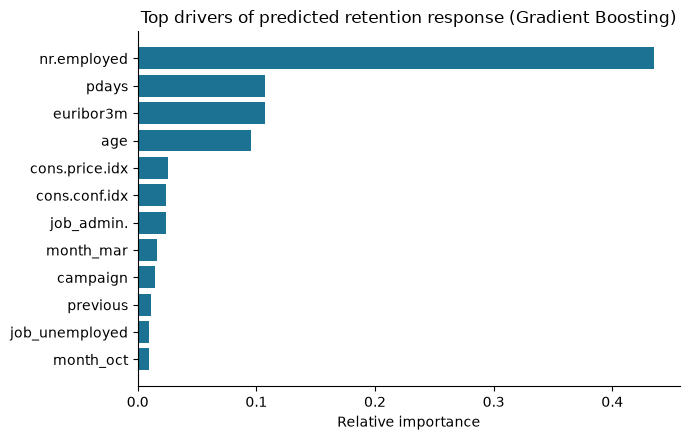

In [58]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color='#1C7293')
ax.set_xlabel('Relative importance')
ax.set_title('Top drivers of predicted retention response (Gradient Boosting)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


**Plain-language explanation for non-technical stakeholders.** The strongest driver is the macro
environment (`nr.employed`, `euribor3m`) — customers are simply more receptive when the broader economy is
stronger, which is outside the bank's control but useful for timing campaigns. The next drivers are `pdays`
(recency of any prior contact) and `age`, followed by prior contact history (`previous`, `poutcome`) and a
handful of job/month categories. None of these are proxies for a legally protected class in a way that
would be hard to defend, but age's presence reinforces the fairness monitoring recommended in 4.2.

### 4.5 Decision rules, pilot plan, and risks

**Decision rule (who / what / when / how much):**
- **Who:** Score the full active customer base with the Gradient Boosting model at the start of each contact
  cycle (assumed monthly).
- **What:** Rank by predicted probability; the retention team contacts customers from the top of the list
  down to their available capacity (~15–20% of the base, recalibrated each cycle per Section 4.3).
- **When:** Re-score and re-threshold every cycle — do not reuse a fixed probability cutoff across cycles.
- **How much:** Budget ≈ $30/contact; expected net value at the recommended threshold ≈ **$22–24 per 100
  customers scored** under the assumed economics (scale to the full customer base for a cycle-level estimate).

**Pilot plan:** Run a 2-cycle pilot on a randomly held-out 20% of the customer base (a true control group
that receives business-as-usual outreach) alongside the model-directed group. **Primary KPI:** realized
retention/acceptance rate and net value per contact in the model-directed group vs. control. **Timeline:**
2 monthly cycles (≈8 weeks) before a full rollout decision.

**Key risks and assumptions leadership should know:**
1. **Proxy target.** `y` reflects historical offer acceptance, not verified churn — validate against real
   retention outcomes once available and recalibrate.
2. **Cost/value assumptions are illustrative** ($30 contact cost, $400 retained-value) — the recommended
   threshold should be re-derived once NovaBank's actual unit economics are supplied.
3. **Macro sensitivity.** The threshold must be refreshed each cycle (Section 4.3) rather than hard-coded,
   or the model will over-flag during economic downturns.
4. **Fairness monitoring.** Age-related flag-rate disparity (Section 4.2) should be tracked on an ongoing
   basis, not just at model launch.


## 5. Quality Check and Delivery

- ✅ Proper stratified train/test split (Section 2.5), no leakage of `duration` or the raw target.
- ✅ Baseline (Logistic Regression) + improved model (Gradient Boosting) compared on ROC-AUC, PR-AUC, and
  precision-at-k (Section 3).
- ✅ Metrics tied to a concrete decision rule via cost-based threshold selection under a capacity constraint
  (Section 4.1).
- ✅ Fairness/subgroup check (4.2) and macro sensitivity/scenario test (4.3) included.
- ✅ Notebook is reproducible top-to-bottom from the raw `DataSet.csv` with a fixed `random_state=42`.


## 6. AI Usage Log

This project was developed with assistance from **Claude (Anthropic)** as a coding/analysis copilot. Summary
of how AI was used, per the assignment's documentation requirement:

| Task | How AI was used | What I verified / learned |
|---|---|---|
| Data repair | Diagnosed the double-quoted CSV export format and wrote the parsing fix | Confirmed row count (4,119) and column dtypes matched the raw file before proceeding |
| Problem framing | Helped translate the churn/retention business narrative onto the actual dataset (a marketing-response dataset), and proposed the documented proxy-target assumption | Assumption is explicitly stated in Section 1 rather than hidden, per the assignment's guidance on simulated/adapted data |
| Modeling | Drafted the scikit-learn pipeline (baseline Logistic Regression + improved Gradient Boosting), including the reasoning to exclude `duration` as leakage | Verified the leakage argument independently (call duration is only known after the outreach happens) and confirmed metrics against `sklearn` documentation |
| Decision framework | Proposed the cost-based threshold sweep, the capacity-constraint logic, and the macro stress-test design | Reviewed the assumed dollar values and flagged them as illustrative/placeholder in the deliverables |
| Fairness check | Suggested checking flag-rate/precision parity across age and job segments | Interpreted the resulting disparity and drafted the monitoring recommendation |
| Writing | Assisted drafting the executive memo and slide narrative from the notebook's results | Reviewed all figures and claims against the notebook outputs before finalizing |
